# EDA — Trailer Comments & Sentiment

Explores `trailer_comments` and `trailer_comments_sentiment` joined with `movies_2025` and `box_office`.

**Strategy**: all heavy aggregations are pushed into SQL. Python only receives:
- one small per-movie summary table (~450 rows)
- pre-computed histograms as bin-count pairs
- a 50 K random text sample (for word frequency)
- a handful of example comments per sentiment class

**Run from the macOS host** — connects via `localhost:5433`.

## 0. Imports and connection

In [17]:
import os, sys, warnings, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# Find python/ regardless of where the notebook is launched from, then chdir
# into it so src.config can resolve ./config.yaml.
def _find_python_root() -> Path:
    cur = Path().resolve()
    for parent in [cur] + list(cur.parents):
        if (parent / "src" / "config.py").exists():
            return parent
    raise RuntimeError("Could not locate python/src/config.py from this notebook")

PYTHON_ROOT = _find_python_root()
os.chdir(PYTHON_ROOT)
sys.path.insert(0, str(PYTHON_ROOT))

from src import config  # noqa: E402

engine = create_engine(
    f"postgresql+psycopg2://{config.POSTGRE_USER}:{config.POSTGRE_PASS}"
    f"@{config.POSTGRE_HOST}:{config.POSTGRE_PORT}/{config.DB_NAME}"
)

FIGURES_DIR = PYTHON_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load aggregated data from SQL

All expensive joins and GROUP BY operations run inside Postgres. Python receives only the resulting summary rows.

In [18]:
# ── Reusable success_target expression ───────────────────────────────────────
SUCCESS_EXPR = """
    CASE
        WHEN bo.opening_weekend_revenue IS NOT NULL
         AND COALESCE(bo.production_budget, m.budget) IS NOT NULL
        THEN CASE WHEN bo.opening_weekend_revenue
                       > 0.25 * COALESCE(bo.production_budget, m.budget)
                  THEN 1 ELSE 0 END
        ELSE NULL
    END
"""

In [19]:
# ── 1a. Per-movie summary ─────────────────────────────────────────────────────
# Includes volume, engagement, word-count avg, anticipation, and leakage check.
SQL_PER_MOVIE = text(f"""
    SELECT  m.tmdb_id,
        m.title,
        m.release_date,
        m.success_target,
        m.comment_count,
        m.comment_count as scored_comments,
        m.trailer_count,
        m.total_likes,
        m.avg_word_count,
        m.first_comment_anticipation AS first_comment_days_before,
        0  AS post_release_count
    FROM final_dataset m
""")

with engine.connect() as conn:
    per_movie = pd.read_sql(SQL_PER_MOVIE, conn, parse_dates=["release_date"])

per_movie["pct_scored"] = (per_movie["scored_comments"] / per_movie["comment_count"]).round(4)
print(f"Movies in per_movie: {len(per_movie):,}")
print(per_movie[["comment_count", "trailer_count", "total_likes", "avg_word_count"]].describe().round(1))

Movies in per_movie: 452
       comment_count  trailer_count  total_likes  avg_word_count
count          410.0          410.0        410.0           410.0
mean          6250.6            3.4     105241.4            12.9
std          15685.6            1.8     199396.4             3.3
min              1.0            1.0          1.0             1.0
25%            322.5            2.0       5428.2            11.3
50%           1508.0            3.0      32317.0            12.7
75%           4902.2            5.0     113944.2            14.2
max         183791.0            9.0    2344904.0            29.3


In [20]:
# ── 1b. Per-movie sentiment aggregates ───────────────────────────────────────
SQL_SENT = text(f"""
    SELECT
        m.tmdb_id,
        {SUCCESS_EXPR}                                                      AS success_target,
        COUNT(s.comment_id)                                                 AS n_scored,
        SUM(CASE WHEN s.label = 'positive' THEN 1 ELSE 0 END)              AS n_positive,
        ROUND(AVG(s.score)::numeric, 4)                                     AS avg_score,
        ROUND(AVG(CASE WHEN s.label='positive' THEN s.score END)::numeric, 4) AS avg_score_pos,
        ROUND(AVG(CASE WHEN s.label='negative' THEN s.score END)::numeric, 4) AS avg_score_neg,
        STRING_AGG(DISTINCT s.model_version, ', ')                          AS model_versions
    FROM public.movies_2025 m
    JOIN public.trailer_comments c          ON m.tmdb_id = c.tmdb_id
    LEFT JOIN public.box_office bo          ON m.tmdb_id = bo.tmdb_id
    JOIN public.trailer_comments_sentiment s ON c.comment_id = s.comment_id
    WHERE m.runtime > 60
    GROUP BY m.tmdb_id, bo.opening_weekend_revenue, bo.production_budget, m.budget
""")

with engine.connect() as conn:
    per_movie_sent = pd.read_sql(SQL_SENT, conn)

per_movie_sent["positive_ratio"] = (per_movie_sent["n_positive"] / per_movie_sent["n_scored"]).round(4)
per_movie_sent["n_negative"]     = per_movie_sent["n_scored"] - per_movie_sent["n_positive"]
p = per_movie_sent["positive_ratio"].clip(1e-9, 1 - 1e-9)
per_movie_sent["controversy_index"] = (1 - (p - 0.5).abs() * 2).round(4)

# Merge title back for display
per_movie_sent = per_movie_sent.merge(per_movie[["tmdb_id", "title"]], on="tmdb_id", how="left")

print(f"Movies with sentiment data: {len(per_movie_sent):,}")
print(per_movie_sent[["positive_ratio", "controversy_index", "avg_score"]].describe().round(4))

Movies with sentiment data: 1,441
       positive_ratio  controversy_index  avg_score
count       1441.0000          1441.0000  1441.0000
mean           0.5555             0.7027     0.8893
std            0.1991             0.2872     0.0624
min            0.0000             0.0000     0.5059
25%            0.4400             0.6102     0.8774
50%            0.5308             0.7960     0.8993
75%            0.6516             0.9120     0.9171
max            1.0000             1.0000     0.9987


In [21]:
# ── 1c. Temporal histogram — days before release (5-day bins, 0–365) ─────────
SQL_TEMPORAL = text("""
    SELECT
        FLOOR(
            GREATEST(EXTRACT(DAY FROM
                (m.release_date::timestamp - c.published_at AT TIME ZONE 'UTC')
            ), 0) / 5
        )::int * 5 AS bin_start,
        COUNT(*)   AS n
    FROM public.trailer_comments c
    JOIN public.movies_2025 m ON m.tmdb_id = c.tmdb_id 
    WHERE m.runtime > 60
      AND EXTRACT(DAY FROM
              (m.release_date::timestamp - c.published_at AT TIME ZONE 'UTC')
          ) BETWEEN 0 AND 365
	 and m.release_date >= '2020-01-01'
    GROUP BY 1
    ORDER BY 1
""")

with engine.connect() as conn:
    temporal_hist = pd.read_sql(SQL_TEMPORAL, conn)

print(f"Temporal histogram bins: {len(temporal_hist)}")
print(f"Total comments in window: {temporal_hist['n'].sum():,}")

Temporal histogram bins: 74
Total comments in window: 2,889,295


In [22]:
# ── 1d. Sentiment score distribution (50 equal-width bins, 0–1) ──────────────
SQL_SCORE_DIST = text("""
    SELECT
        label,
        FLOOR(score * 50)::int AS bin,   -- bin 0..49 maps to [0,0.02), [0.02,0.04) …
        COUNT(*) AS n
    FROM public.trailer_comments_sentiment
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

with engine.connect() as conn:
    score_dist = pd.read_sql(SQL_SCORE_DIST, conn)

score_dist["score_mid"] = score_dist["bin"] / 50 + 0.01
print(score_dist.groupby("label")["n"].sum())

label
negative    1606088
positive    1496603
Name: n, dtype: int64


In [23]:
# ── 1e. Sentiment arc — comment volume + positive ratio by 2-week bins ────────
SQL_ARC = text("""
    SELECT
        FLOOR(
            EXTRACT(DAY FROM
                (m.release_date::timestamp - c.published_at AT TIME ZONE 'UTC')
            ) / 14
        )::int * 14 AS week_bin,
        COUNT(*) AS n,
        ROUND(
            AVG(CASE WHEN s.label = 'positive' THEN 1.0 ELSE 0.0 END)::numeric, 4
        ) AS pos_ratio
    FROM public.trailer_comments c
    JOIN public.movies_2025 m ON m.tmdb_id = c.tmdb_id
    JOIN public.trailer_comments_sentiment s ON s.comment_id = c.comment_id
    WHERE m.runtime > 60
      AND EXTRACT(DAY FROM
              (m.release_date::timestamp - c.published_at AT TIME ZONE 'UTC')
          ) BETWEEN 0 AND 180
      and m.release_date >= '2020-01-01'
    GROUP BY 1
    ORDER BY 1
""")

with engine.connect() as conn:
    arc_agg = pd.read_sql(SQL_ARC, conn)

print(arc_agg)

    week_bin       n  pos_ratio
0          0  444099     0.4652
1         14  492600     0.5021
2         28  270643     0.5045
3         42  247121     0.4941
4         56  194152     0.4654
5         70  168306     0.4946
6         84  208477     0.4657
7         98  160760     0.4659
8        112  145773     0.4682
9        126  141752     0.4849
10       140  159288     0.4416
11       154   70227     0.4242
12       168   38509     0.4852


In [24]:
# ── 1f. Likes by sentiment label (summary stats) ──────────────────────────────
SQL_LIKES_SENT = text("""
    SELECT
        s.label,
        COUNT(*)                                                        AS n,
        ROUND(AVG(c.like_count)::numeric, 2)                            AS avg_likes,
        PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY c.like_count)      AS median_likes,
        PERCENTILE_CONT(0.9)  WITHIN GROUP (ORDER BY c.like_count)      AS p90_likes,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY c.like_count)      AS p99_likes
    FROM public.trailer_comments c
    JOIN public.trailer_comments_sentiment s ON s.comment_id = c.comment_id
    WHERE c.like_count IS NOT NULL AND c.like_count >= 0
    GROUP BY 1
""")

with engine.connect() as conn:
    likes_by_sent = pd.read_sql(SQL_LIKES_SENT, conn)

print(likes_by_sent.to_string(index=False))

   label       n  avg_likes  median_likes  p90_likes  p99_likes
negative 1606088      10.96           0.0        2.0       76.0
positive 1496603      21.47           0.0        2.0      233.0


In [25]:
# ── 1g. 50 K random comments for text/word-count analysis ────────────────────
SQL_SAMPLE = text("""
    SELECT c.text, c.like_count,
           COALESCE(s.label, 'unscored') AS sentiment_label,
           EXTRACT(DAY FROM
               (m.release_date::timestamp - c.published_at AT TIME ZONE 'UTC')
           )::int AS days_before_release
    FROM public.trailer_comments c
    JOIN public.movies_2025 m ON m.tmdb_id = c.tmdb_id
    LEFT JOIN public.trailer_comments_sentiment s ON s.comment_id = c.comment_id
    WHERE m.runtime > 60 AND c.text IS NOT NULL AND trim(c.text) != ''
    and m.release_date >= '2020-01-01'
    ORDER BY RANDOM()
    LIMIT 50000
""")

with engine.connect() as conn:
    text_sample = pd.read_sql(SQL_SAMPLE, conn)

text_sample["word_count"] = text_sample["text"].str.split().str.len()
print(f"Text sample: {len(text_sample):,} rows")
print(text_sample["word_count"].describe(percentiles=[.5,.9,.95,.99]).round(1))

Text sample: 50,000 rows
count    50000.0
mean        11.6
std         14.5
min          1.0
50%          8.0
90%         24.0
95%         34.0
99%         71.0
max        206.0
Name: word_count, dtype: float64


In [26]:
# ── 1h. High-confidence comment examples (tiny) ───────────────────────────────
SQL_EXAMPLES = text("""
    SELECT s.label, s.score, c.text
    FROM public.trailer_comments_sentiment s
    JOIN public.trailer_comments c ON s.comment_id = c.comment_id
    WHERE s.score > 0.97
      AND c.text IS NOT NULL
      AND array_length(regexp_split_to_array(trim(c.text), '\\s+'), 1) >= 4
    ORDER BY RANDOM()
    LIMIT 200
""")

with engine.connect() as conn:
    examples = pd.read_sql(SQL_EXAMPLES, conn)

print(examples["label"].value_counts())

label
positive    100
negative    100
Name: count, dtype: int64


In [27]:
# ── 1i. Leakage check ─────────────────────────────────────────────────────────
SQL_LEAKAGE = text("""
    SELECT COUNT(*) AS n_leakage
    FROM public.trailer_comments c
    JOIN public.movies_2025 m ON m.tmdb_id = c.tmdb_id
    WHERE (c.published_at AT TIME ZONE 'UTC')::date >= m.release_date
""")

with engine.connect() as conn:
    n_leakage = conn.execute(SQL_LEAKAGE).scalar()

if n_leakage == 0:
    print("No leakage — all comments are strictly before release date.")
else:
    print(f"WARNING: {n_leakage:,} comments are on or after the release date!")

# Also surface movies that had any post-release comments
leaky_movies = per_movie[per_movie["post_release_count"] > 0][["title", "post_release_count"]]
if leaky_movies.empty:
    print("No movies with post-release comments in per_movie summary.")
else:
    print(leaky_movies)

No leakage — all comments are strictly before release date.
No movies with post-release comments in per_movie summary.


## 2. Comment volume per movie

In [28]:
print("Top 10 movies by comment count:")
print(per_movie[["title", "comment_count", "trailer_count", "total_likes", "pct_scored"]]
      .head(10).to_string(index=False))

Top 10 movies by comment count:
                       title  comment_count  trailer_count  total_likes  pct_scored
    Avatar: The Way of Water        38215.0            6.0     437234.0         1.0
        Avatar: Fire and Ash        37655.0            6.0     790522.0         1.0
                 Expend4bles         7745.0            4.0      41904.0         1.0
Puss in Boots: The Last Wish            NaN            NaN          NaN         NaN
           In the Lost Lands          306.0            2.0      13269.0         1.0
                   Uncharted        25355.0            4.0     311150.0         1.0
                     Cruella         7466.0            4.0     177606.0         1.0
                   Bloodshot         8584.0            6.0      78586.0         1.0
                      Barbie         3888.0            2.0     404911.0         1.0
           Top Gun: Maverick        24558.0            2.0     270177.0         1.0


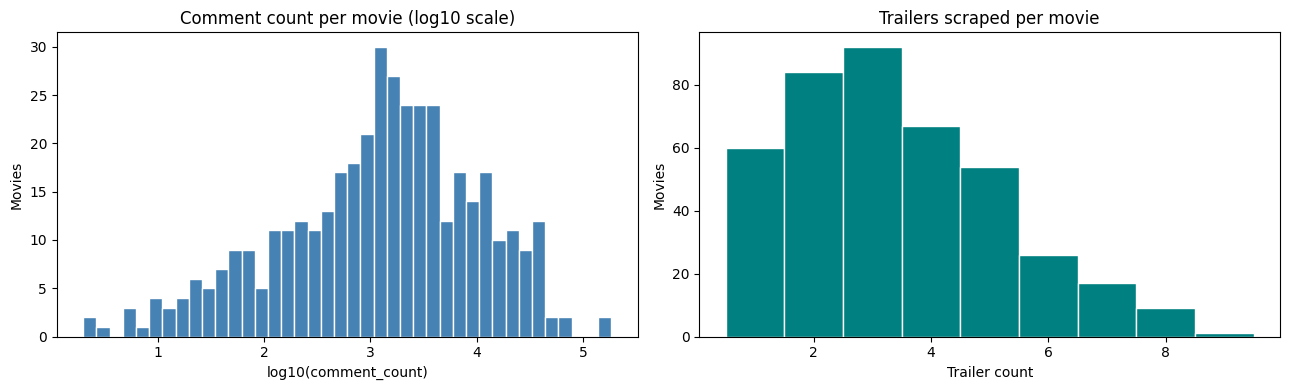

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log1p(per_movie["comment_count"])/np.log(10), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Comment count per movie (log10 scale)")
axes[0].set_xlabel("log10(comment_count)")
axes[0].set_ylabel("Movies")

axes[1].hist(per_movie["trailer_count"],
             bins=range(1, int(per_movie["trailer_count"].max()) + 2),
             color="teal", edgecolor="white", align="left")
axes[1].set_title("Trailers scraped per movie")
axes[1].set_xlabel("Trailer count")
axes[1].set_ylabel("Movies")

plt.tight_layout(); plt.show()

/tmp/ipykernel_85448/1222394782.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled, x="success_target", y="comment_count",
/tmp/ipykernel_85448/1222394782.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Failure (0)", "Success (1)"]); axes[0].set_xlabel("")
/tmp/ipykernel_85448/1222394782.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled, x="success_target", y="pct_scored",
/tmp/ipykernel_85448/1222394782.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].

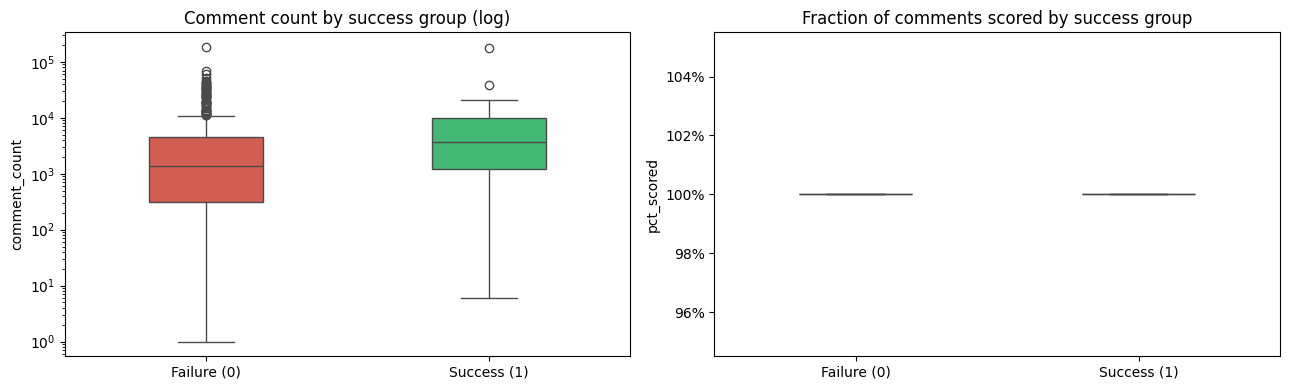

In [30]:
labeled = per_movie[per_movie["success_target"].notna()].copy()
labeled["success_target"] = labeled["success_target"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=labeled, x="success_target", y="comment_count",
            palette=["#e74c3c", "#2ecc71"], width=0.4, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Comment count by success group (log)")
axes[0].set_xticklabels(["Failure (0)", "Success (1)"]); axes[0].set_xlabel("")

sns.boxplot(data=labeled, x="success_target", y="pct_scored",
            palette=["#e74c3c", "#2ecc71"], width=0.4, ax=axes[1])
axes[1].set_title("Fraction of comments scored by success group")
axes[1].set_xticklabels(["Failure (0)", "Success (1)"]); axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout(); plt.show()

## 3. Temporal patterns — when do comments arrive?

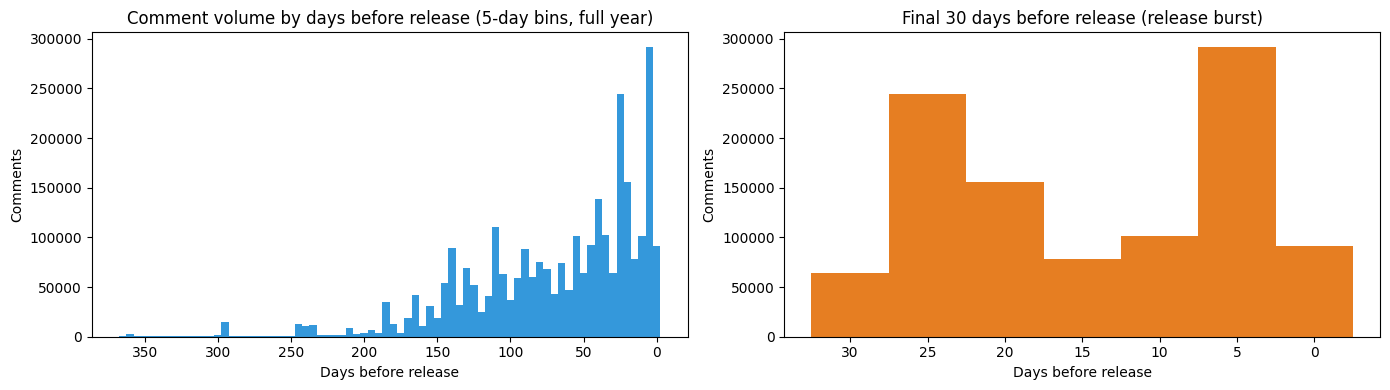

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full 0-365 window
axes[0].bar(temporal_hist["bin_start"], temporal_hist["n"], width=5,
            color="#3498db", edgecolor="none")
axes[0].set_title("Comment volume by days before release (5-day bins, full year)")
axes[0].set_xlabel("Days before release")
axes[0].set_ylabel("Comments")
axes[0].invert_xaxis()

# Final 30 days
close = temporal_hist[temporal_hist["bin_start"] <= 30]
axes[1].bar(close["bin_start"], close["n"], width=5,
            color="#e67e22", edgecolor="none")
axes[1].set_title("Final 30 days before release (release burst)")
axes[1].set_xlabel("Days before release")
axes[1].set_ylabel("Comments")
axes[1].invert_xaxis()

plt.tight_layout(); plt.show()

/tmp/ipykernel_85448/4212018188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_ant, x="success_target", y="first_comment_days_before",
/tmp/ipykernel_85448/4212018188.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Failure (0)", "Success (1)"]); ax.set_xlabel("")


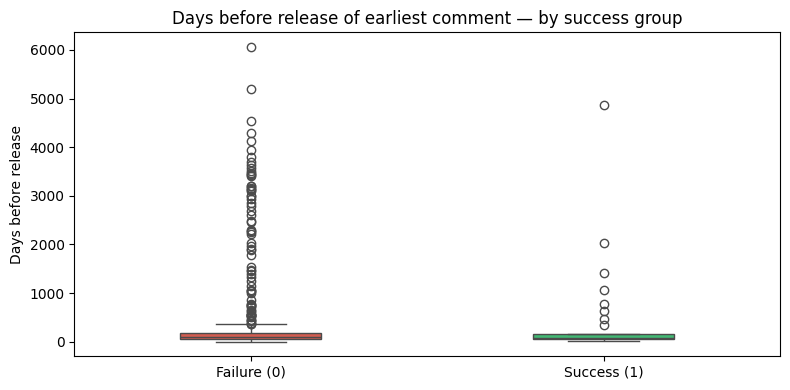

In [32]:
# Earliest comment (anticipation) by success group
labeled_ant = per_movie[per_movie["success_target"].notna()].copy()
labeled_ant["success_target"] = labeled_ant["success_target"].astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=labeled_ant, x="success_target", y="first_comment_days_before",
            palette=["#e74c3c", "#2ecc71"], width=0.4, ax=ax)
ax.set_title("Days before release of earliest comment — by success group")
ax.set_xticklabels(["Failure (0)", "Success (1)"]); ax.set_xlabel("")
ax.set_ylabel("Days before release")
plt.tight_layout(); plt.show()

## 4. Engagement — likes

In [33]:
# Like distribution from the text sample (50 K rows)
likes = text_sample["like_count"].dropna()
print(likes.describe(percentiles=[.5, .75, .9, .95, .99]).round(1))
print(f"\n0-like comments : {(likes == 0).mean():.1%}")
print(f"≥10-like comments: {(likes >= 10).mean():.1%}")

count    50000.0
mean        18.3
std        598.8
min          0.0
50%          0.0
75%          1.0
90%          2.0
95%          5.0
99%        140.0
max      82865.0
Name: like_count, dtype: float64

0-like comments : 72.3%
≥10-like comments: 3.6%


/tmp/ipykernel_85448/4245975957.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_likes, x="success_target", y="total_likes",
/tmp/ipykernel_85448/4245975957.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Failure (0)", "Success (1)"]); axes[1].set_xlabel("")


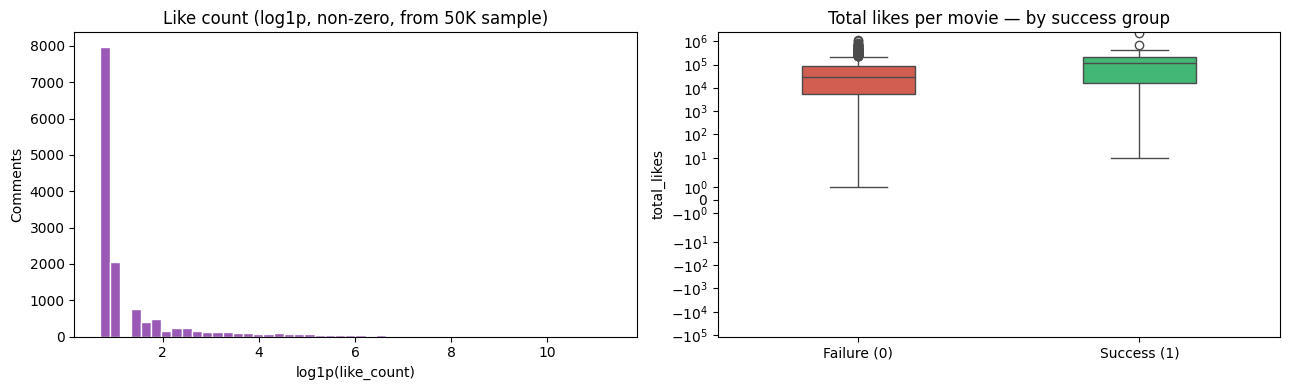

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nz = likes[likes > 0]
axes[0].hist(np.log1p(nz), bins=50, color="#9b59b6", edgecolor="white")
axes[0].set_title("Like count (log1p, non-zero, from 50K sample)")
axes[0].set_xlabel("log1p(like_count)")
axes[0].set_ylabel("Comments")

labeled_likes = per_movie[per_movie["success_target"].notna()].copy()
labeled_likes["success_target"] = labeled_likes["success_target"].astype(int)
sns.boxplot(data=labeled_likes, x="success_target", y="total_likes",
            palette=["#e74c3c", "#2ecc71"], width=0.4, ax=axes[1])
axes[1].set_yscale("symlog")
axes[1].set_title("Total likes per movie — by success group")
axes[1].set_xticklabels(["Failure (0)", "Success (1)"]); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

## 5. Comment text — length and vocabulary

Based on the 50 K random sample.

In [35]:
print("Word count summary (50K sample):")
wc = text_sample["word_count"]
print(wc.describe(percentiles=[.5, .75, .9, .95, .99]).round(1))
print(f"\n≤3 words : {(wc <= 3).mean():.1%}")
print(f"≥50 words: {(wc >= 50).mean():.1%}")

Word count summary (50K sample):
count    50000.0
mean        11.6
std         14.5
min          1.0
50%          8.0
75%         14.0
90%         24.0
95%         34.0
99%         71.0
max        206.0
Name: word_count, dtype: float64

≤3 words : 22.4%
≥50 words: 2.3%


/tmp/ipykernel_85448/3882677680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_wc, x="success_target", y="avg_word_count",
/tmp/ipykernel_85448/3882677680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Failure (0)", "Success (1)"]); axes[1].set_xlabel("")


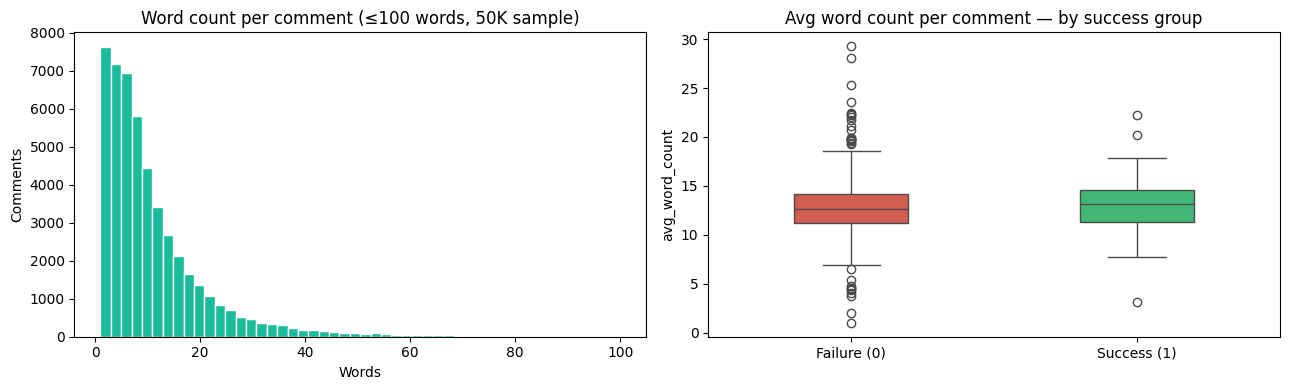

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(wc[wc <= 100], bins=50, color="#1abc9c", edgecolor="white")
axes[0].set_title("Word count per comment (≤100 words, 50K sample)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Comments")

# Avg word count per movie from SQL summary
labeled_wc = per_movie[per_movie["success_target"].notna()].copy()
labeled_wc["success_target"] = labeled_wc["success_target"].astype(int)
sns.boxplot(data=labeled_wc, x="success_target", y="avg_word_count",
            palette=["#e74c3c", "#2ecc71"], width=0.4, ax=axes[1])
axes[1].set_title("Avg word count per comment — by success group")
axes[1].set_xticklabels(["Failure (0)", "Success (1)"]); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

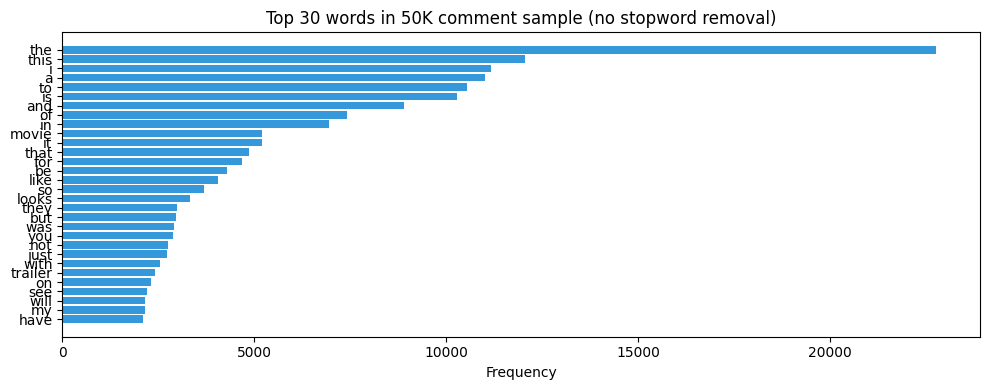

In [37]:
all_words = " ".join(text_sample["text"].dropna().str.lower()).split()
top_words = pd.DataFrame(Counter(all_words).most_common(30), columns=["word", "count"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_words["word"][::-1], top_words["count"][::-1], color="#3498db")
ax.set_title("Top 30 words in 50K comment sample (no stopword removal)")
ax.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

## 6. Sentiment — label balance and score distribution

In [38]:
label_totals = score_dist.groupby("label")["n"].sum()
total_scored = label_totals.sum()
total_comments = per_movie["comment_count"].sum()

print(f"Total comments         : {total_comments:,}")
print(f"Scored comments        : {total_scored:,}  ({total_scored/total_comments:.1%})")
print(label_totals.to_string())
print(f"\nModel versions: {per_movie_sent['model_versions'].dropna().unique()}")

Total comments         : 2,562,756.0
Scored comments        : 3,102,691  (121.1%)
label
negative    1606088
positive    1496603

Model versions: ['bert-tiny-imdb-final']


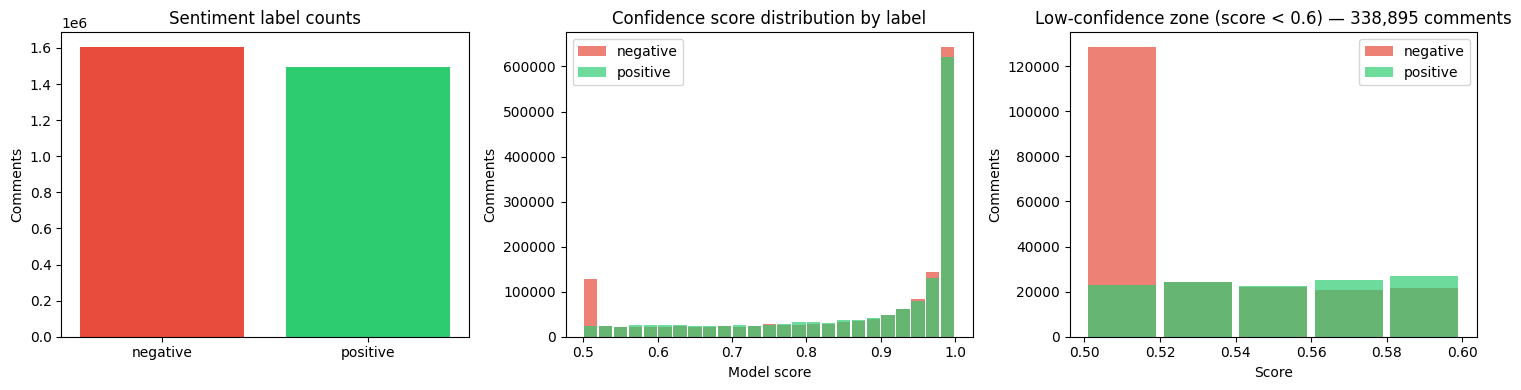

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label counts
colors_map = {"positive": "#2ecc71", "negative": "#e74c3c"}
axes[0].bar(label_totals.index, label_totals.values,
            color=[colors_map.get(l, "grey") for l in label_totals.index])
axes[0].set_title("Sentiment label counts")
axes[0].set_ylabel("Comments")

# Score distribution by label
for label, grp in score_dist.groupby("label"):
    axes[1].bar(grp["score_mid"], grp["n"], width=0.018,
                alpha=0.7, label=label, color=colors_map.get(label, "grey"))
axes[1].set_title("Confidence score distribution by label")
axes[1].set_xlabel("Model score")
axes[1].set_ylabel("Comments")
axes[1].legend()

# Low-confidence zone
low = score_dist[score_dist["score_mid"] < 0.6]
low_n = low["n"].sum()
for label, grp in low.groupby("label"):
    axes[2].bar(grp["score_mid"], grp["n"], width=0.018,
                alpha=0.7, label=label, color=colors_map.get(label, "grey"))
axes[2].set_title(f"Low-confidence zone (score < 0.6) — {low_n:,} comments")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Comments")
axes[2].legend()

plt.tight_layout(); plt.show()

## 7. Sentiment aggregated per movie

In [40]:
print("Most positive movies (≥100 scored):")
stable = per_movie_sent[per_movie_sent["n_scored"] >= 100]
print(stable.nlargest(5, "positive_ratio")[["title", "n_scored", "positive_ratio", "success_target"]]
      .to_string(index=False))
print("\nMost negative movies:")
print(stable.nsmallest(5, "positive_ratio")[["title", "n_scored", "positive_ratio", "success_target"]]
      .to_string(index=False))

Most positive movies (≥100 scored):
title  n_scored  positive_ratio  success_target
  NaN       101          0.8911             1.0
  NaN      2364          0.8811             NaN
  NaN       327          0.8654             NaN
  NaN       220          0.8318             NaN
  NaN       133          0.8271             NaN

Most negative movies:
title  n_scored  positive_ratio  success_target
  NaN       128          0.2109             NaN
  NaN       100          0.2200             1.0
  NaN       119          0.2353             1.0
  NaN       989          0.2447             NaN
  NaN       167          0.2515             NaN


/tmp/ipykernel_85448/125288670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_sent, x="success_target", y=col,
/tmp/ipykernel_85448/125288670.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Failure (0)", "Success (1)"]); ax.set_xlabel("")
/tmp/ipykernel_85448/125288670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_sent, x="success_target", y=col,
/tmp/ipykernel_85448/125288670.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Failure (0)",

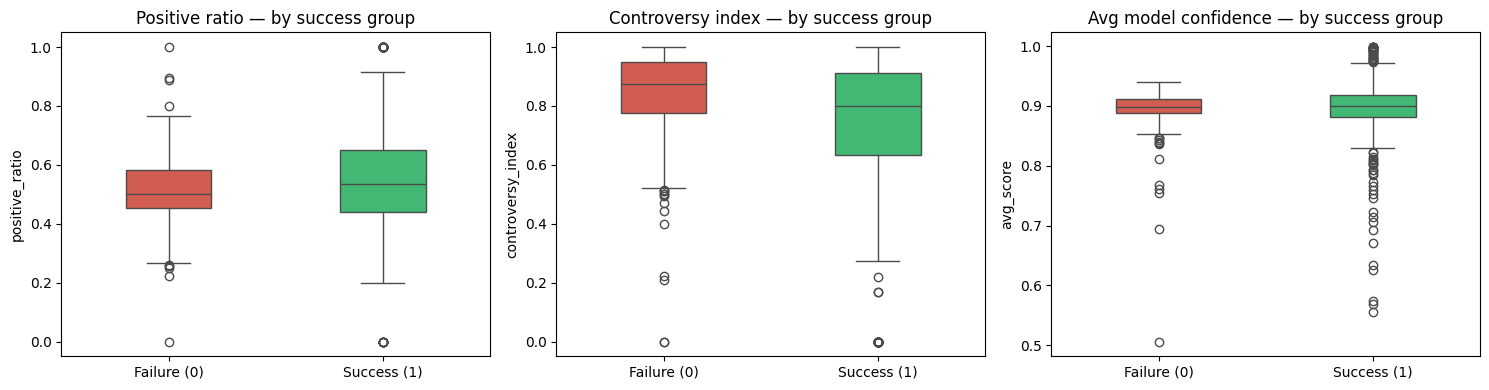

In [41]:
labeled_sent = per_movie_sent[per_movie_sent["success_target"].notna()].copy()
labeled_sent["success_target"] = labeled_sent["success_target"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
    ["positive_ratio", "controversy_index", "avg_score"],
    ["Positive ratio", "Controversy index", "Avg model confidence"]):
    sns.boxplot(data=labeled_sent, x="success_target", y=col,
                palette=["#e74c3c", "#2ecc71"], width=0.4, ax=ax)
    ax.set_title(f"{title} — by success group")
    ax.set_xticklabels(["Failure (0)", "Success (1)"]); ax.set_xlabel("")
plt.tight_layout(); plt.show()

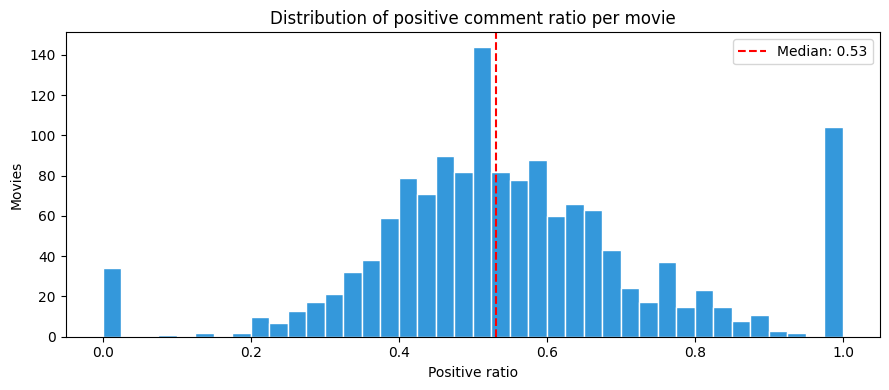

In [42]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(per_movie_sent["positive_ratio"], bins=40, color="#3498db", edgecolor="white")
med = per_movie_sent["positive_ratio"].median()
ax.axvline(med, color="red", linestyle="--", label=f"Median: {med:.2f}")
ax.set_title("Distribution of positive comment ratio per movie")
ax.set_xlabel("Positive ratio"); ax.set_ylabel("Movies")
ax.legend()
plt.tight_layout(); plt.show()

## 8. Sentiment vs. engagement (likes)

   label       n  avg_likes  median_likes  p90_likes  p99_likes
negative 1606088      10.96           0.0        2.0       76.0
positive 1496603      21.47           0.0        2.0      233.0


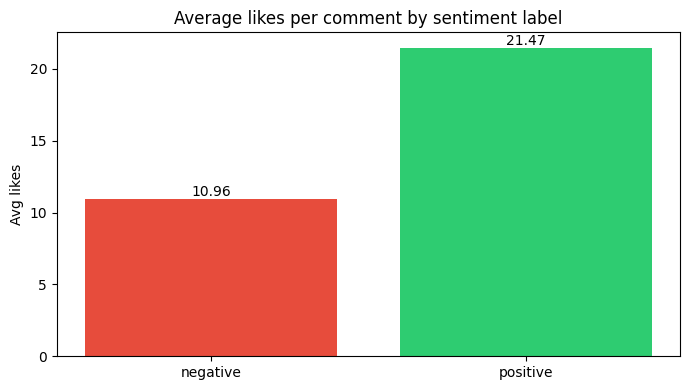

In [43]:
print(likes_by_sent.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(likes_by_sent["label"], likes_by_sent["avg_likes"],
       color=[colors_map.get(l, "grey") for l in likes_by_sent["label"]])
ax.set_title("Average likes per comment by sentiment label")
ax.set_ylabel("Avg likes")
for i, row in likes_by_sent.iterrows():
    ax.text(i, row["avg_likes"] + 0.01, f'{row["avg_likes"]:.2f}', ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 9. Sentiment over time — anticipation arc

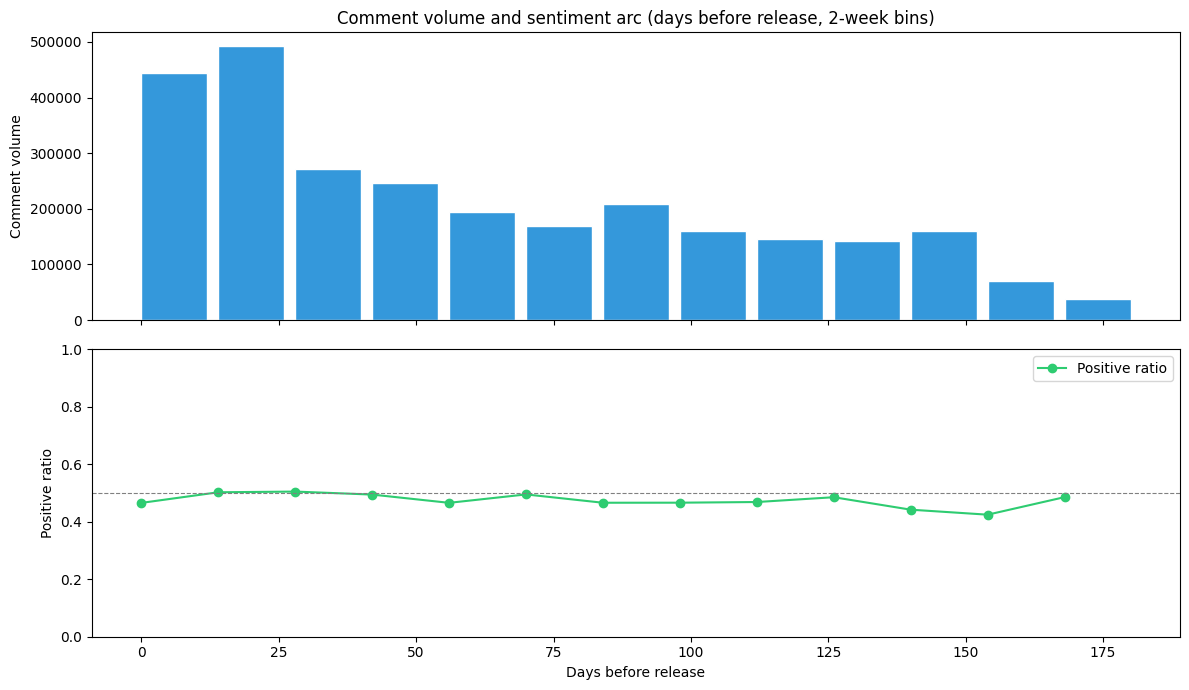

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(arc_agg["week_bin"], arc_agg["n"], width=12,
            color="#3498db", edgecolor="white", align="edge")
axes[0].set_ylabel("Comment volume")
axes[0].set_title("Comment volume and sentiment arc (days before release, 2-week bins)")
axes[0].invert_xaxis()

axes[1].plot(arc_agg["week_bin"], arc_agg["pos_ratio"],
             marker="o", color="#2ecc71", label="Positive ratio")
axes[1].axhline(0.5, color="grey", linestyle="--", lw=0.8)
axes[1].set_ylabel("Positive ratio")
axes[1].set_xlabel("Days before release")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].invert_xaxis()

plt.tight_layout(); plt.show()

## 10. Top / bottom movies by positive ratio

In [45]:
top10    = stable.nlargest(10,  "positive_ratio")
bottom10 = stable.nsmallest(10, "positive_ratio")
extremes = pd.concat([top10, bottom10]).drop_duplicates().sort_values("positive_ratio")

bar_colors = ["#2ecc71" if r >= 0.5 else "#e74c3c" for r in extremes["positive_ratio"]]
labels_plot = [textwrap.shorten(t, 35) for t in extremes["title"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(labels_plot, extremes["positive_ratio"], color=bar_colors)
ax.axvline(0.5, color="grey", linestyle="--", lw=0.8)
ax.set_xlabel("Positive ratio")
ax.set_title("Top / bottom 10 movies by positive comment ratio (≥100 scored)")
plt.tight_layout(); plt.show()

AttributeError: 'float' object has no attribute 'strip'

## 11. Sample comments — sanity check

In [ ]:
def show_examples(label, n=8):
    rows = examples[examples["label"] == label].sample(min(n, len(examples[examples["label"] == label])),
                                                        random_state=42)
    for _, row in rows.iterrows():
        print(f"[{row['score']:.3f}] {textwrap.fill(str(row['text'])[:200], 100)}")
        print()

print("=== HIGH-CONFIDENCE POSITIVE ===")
show_examples("positive")
print("=== HIGH-CONFIDENCE NEGATIVE ===")
show_examples("negative")

## 12. Correlation — social features × success_target

In [ ]:
social = (
    per_movie[["tmdb_id", "success_target", "comment_count", "total_likes",
               "trailer_count", "avg_word_count", "first_comment_days_before"]]
    .merge(per_movie_sent[["tmdb_id", "positive_ratio", "controversy_index", "avg_score"]],
           on="tmdb_id", how="left")
    .dropna(subset=["success_target"])
)
social["success_target"] = social["success_target"].astype(float)

corr = social.drop(columns="tmdb_id").corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", center=0,
            cmap="RdYlGn", linewidths=0.5, ax=ax, square=True)
ax.set_title("Spearman correlation — social features × success_target")
plt.tight_layout(); plt.show()

In [ ]:
target_corr = corr["success_target"].drop("success_target").sort_values(key=abs, ascending=False)
print("Spearman ρ with success_target:")
print(target_corr.round(4).to_string())

## 13. Summary and notes for modelling

- **Volume skew**: comment counts are heavily right-skewed — use `log1p` transform.
- **Sentiment coverage**: check Section 6 — the fraction of comments scored vs. total is the reliability ceiling for any sentiment feature.
- **Positive ratio vs. success**: Section 7 shows whether sentiment separates the two groups.
- **Controversy index**: derived from positive ratio — captures polarisation; keep as a separate feature.
- **Anticipation (`first_comment_days_before`)**: earliest-comment date relative to release; Section 3 shows group separation.
- **Low-confidence zone**: the Section 6 histogram of scores < 0.6 tells you how much noise the DistilBERT model introduces.
- **Leakage**: Section 1i confirms whether all comments are strictly before release.